In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# List files in your Drive to verify mount and file existence
!ls "/content/drive/MyDrive"

'Colab Notebooks'	     iot_professional	    'S2-Basics of Python.mp4'
 datasets		     langchain		    'S8-boston housing(regression).ipynb'
'Data visualization'	    'my deep learning'	     Untitled0.ipynb
'deep learning-davoodpoor'   my_model.keras	     Untitled1.ipynb
'House prediction.csv'	    'Opencv and mediapipe'   winequalityN.csv
 Iot_basics		    'Python course'


In [16]:
# List files in the target directory to verify the path and file existence
!ls "/content/drive/MyDrive/datasets/cat and dog"

'رونوشت input.csv'  'رونوشت input_test.csv'  'رونوشت labels.csv'  'رونوشت labels_test.csv'


In [17]:
X_train = np.loadtxt('/content/drive/MyDrive/datasets/cat and dog/input.csv', delimiter = ',')
Y_train = np.loadtxt('/content/drive/MyDrive/datasets/cat and dog/labels.csv', delimiter = ',')

X_test = np.loadtxt('/content/drive/MyDrive/datasets/cat and dog/input_test.csv', delimiter = ',')
Y_test = np.loadtxt('/content/drive/MyDrive/datasets/cat and dog/labels_test.csv', delimiter = ',')

In [18]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
#
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train/255.0
X_test = X_test/255.0

In [19]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


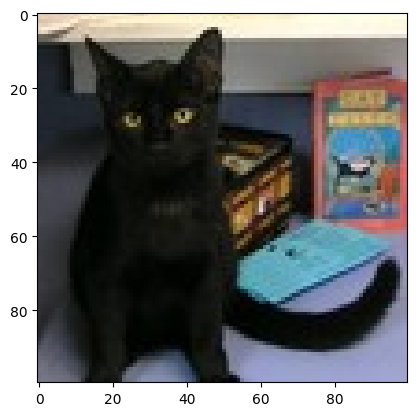

In [20]:
idx = random.randint(0, len(X_train))
plt.imshow(X_train[idx, :])
plt.show()

In [21]:

model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (100, 100, 3)),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (100, 100, 3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [23]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [24]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 64)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 788ms/step - accuracy: 0.5196 - loss: 0.7738
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 711ms/step - accuracy: 0.6440 - loss: 0.6504
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 758ms/step - accuracy: 0.7021 - loss: 0.5796
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 742ms/step - accuracy: 0.6525 - loss: 0.6016
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 735ms/step - accuracy: 0.7546 - loss: 0.5422


In [25]:
model.evaluate(X_test, Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7063 - loss: 0.5734


[0.5859617590904236, 0.6875]

Model prediction

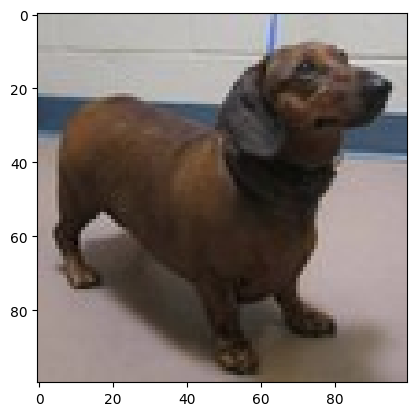

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Our model says it is a : dog


In [27]:
idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'dog'
else:
    pred = 'cat'

print("Our model says it is a :", pred)